# E-Commerce Data Cleaning Project
### Python + Pandas + Matplotlib + Seaborn

**Skills covered:** Multi-file loading, Regex cleaning, Robust date parsing, Missing value strategies, Merge/Join, GroupBy analysis, 8 Visualizations

**Files:** `customers.csv` | `products.csv` | `orders.csv` | `order_items.csv` | `returns.csv`

---

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, os, warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

RAW   = 'raw_data'
CLEAN = 'cleaned_data'
VIZ   = 'visualizations'
os.makedirs(CLEAN, exist_ok=True)
os.makedirs(VIZ,   exist_ok=True)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2 — Load All 5 Raw Datasets
We load all files at once and immediately check their shapes.

In [2]:
cust   = pd.read_csv(f'{RAW}/customers.csv')
prod   = pd.read_csv(f'{RAW}/products.csv')
orders = pd.read_csv(f'{RAW}/orders.csv')
items  = pd.read_csv(f'{RAW}/order_items.csv')
ret    = pd.read_csv(f'{RAW}/returns.csv')

datasets = {'customers': cust, 'products': prod, 'orders': orders,
            'order_items': items, 'returns': ret}

print('=== RAW DATASET SHAPES ==='.center(42))
for name, df in datasets.items():
    print(f'  {name:<15}: {df.shape[0]:>5} rows x {df.shape[1]:>2} columns')

        === RAW DATASET SHAPES ===        
  customers      :  1000 rows x 10 columns
  products       :   200 rows x  9 columns
  orders         :  1500 rows x 12 columns
  order_items    :  3000 rows x  7 columns
  returns        :   300 rows x  7 columns


## Step 3 — Full Data Audit
Before touching anything, we audit ALL files for problems: missing values, duplicates, data types, and unique value inconsistencies.

In [3]:
print('=== MISSING VALUES ACROSS ALL FILES ===')
for name, df in datasets.items():
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f'\n{name}:')
        print(missing[missing > 0])

=== MISSING VALUES ACROSS ALL FILES ===

customers:
email    177
phone    334
age      190
dtype: int64

products:
price          3
cost_price     4
stock_qty     53
rating         2
dtype: int64

orders:
ship_date          139
order_amount        22
discount_amount     16
dtype: int64

order_items:
quantity        39
unit_price      61
item_total      95
discount_pct    41
dtype: int64

returns:
return_date      89
refund_amount     1
dtype: int64


In [4]:
print('=== DUPLICATE ROWS ==='.center(34))
for name, df in datasets.items():
    dups = df.duplicated().sum()
    print(f'  {name:<15}: {dups} duplicate rows')

      === DUPLICATE ROWS ===      
  customers      : 0 duplicate rows
  products       : 0 duplicate rows
  orders         : 0 duplicate rows
  order_items    : 0 duplicate rows
  returns        : 0 duplicate rows


In [5]:
print('=== DATA TYPES ==='.center(28))
for name, df in datasets.items():
    print(f'\n{name}:')
    print(df.dtypes)

     === DATA TYPES ===     

customers:
customer_id           object
customer_name         object
email                 object
phone                 object
age                  float64
gender                object
city                  object
state                 object
customer_segment      object
registration_date     object
dtype: object

products:
product_id       object
product_name     object
category         object
sub_category     object
brand            object
price           float64
cost_price      float64
stock_qty       float64
rating          float64
dtype: object

orders:
order_id            object
customer_id         object
order_date          object
ship_date           object
order_status        object
payment_method      object
sales_channel       object
order_amount       float64
discount_amount    float64
shipping_fee         int64
city                object
state               object
dtype: object

order_items:
item_id          object
order_id         object
produ

In [6]:
# Spot inconsistent text values
print('Unique gender values:  ', cust['gender'].unique())
print("-"*88, "\n")
print('Unique segment values: ', cust['customer_segment'].unique())
print("-"*88, "\n")
print('Unique order_status:   ', orders['order_status'].unique())
print("-"*88, "\n")
print('Unique payment_method: ', orders['payment_method'].unique())
print("-"*88, "\n")
print('Unique category:       ', prod['category'].unique())
print("-"*88, "\n")

Unique gender values:   ['M' 'F' 'female' 'Other' 'f' 'MALE' 'FEMALE' 'male' 'm' 'Male' 'Female']
---------------------------------------------------------------------------------------- 

Unique segment values:  ['home office' 'Consumer' 'CORPORATE' 'consumer' 'Corporate' 'Home Office']
---------------------------------------------------------------------------------------- 

Unique order_status:    ['SHIPPED' 'returned' 'CANCELLED' 'pending' 'Returned' 'Delivered'
 'Cancelled' 'delivered' 'Shipped' 'Pending']
---------------------------------------------------------------------------------------- 

Unique payment_method:  ['credit card' 'Debit Card' 'UPI' 'UPI ' 'Net Banking' 'COD' 'Credit Card'
 'WALLET' '  COD' 'Wallet']
---------------------------------------------------------------------------------------- 

Unique category:        ['Home & Kitchen' 'Sports' 'Electronics' 'Clothing' 'electronics'
 'CLOTHING' 'books' 'Books' 'sports' 'HOME & KITCHEN']
-----------------------------

## Step 4 — Build a Robust Date Parser
The datasets have **mixed date formats**: `2024-01-15`, `15/01/2024`, `01-15-2024`, etc.  
A single `pd.to_datetime()` call can't handle all of them — it leaves `NaT` (Not a Time).  
We build a custom parser that tries **11 formats** per value, eliminating NaT completely.

```
Formats handled:
  %Y-%m-%d   → 2024-01-15
  %d/%m/%Y   → 15/01/2024
  %m/%d/%Y   → 01/15/2024
  %d-%m-%Y   → 15-01-2024
  %m-%d-%Y   → 01-15-2024  (US format)
  %Y/%m/%d   → 2024/01/15
  %d %b %Y   → 15 Jan 2024
  %b %d %Y   → Jan 15 2024
  %d-%b-%Y   → 15-Jan-2024
```

In [7]:
def parse_single_date(val):
    """Try 11 explicit date formats. Returns pd.NaT only if all fail."""
    if pd.isna(val) or str(val).strip() == '':
        return pd.NaT
    val = str(val).strip()
    formats = [
        '%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y',
        '%d-%m-%Y', '%m-%d-%Y', '%Y/%m/%d',
        '%d.%m.%Y', '%m.%d.%Y',
        '%d %b %Y', '%b %d %Y', '%d-%b-%Y',
    ]
    for fmt in formats:
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            continue
    return pd.to_datetime(val, errors='coerce')  # last resort

def parse_dates_robust(series):
    """Apply multi-format parser to every value in a Series."""
    return series.apply(parse_single_date)

# Quick test
test_dates = pd.Series(['2024-01-15', '15/01/2024', '01-15-2024', '15-Jan-2024', None])
print('Test robust parser:')
print(parse_dates_robust(test_dates))

Test robust parser:
0   2024-01-15
1   2024-01-15
2   2024-01-15
3   2024-01-15
4          NaT
dtype: datetime64[ns]


## Step 5 — Clean customers.csv
Problems: duplicates, invalid emails, messy phone numbers, invalid ages, inconsistent gender/segment, mixed date formats.

In [8]:
print('Rows BEFORE:', len(cust))
print("-"*88, "\n")

# 1. Remove duplicates
cust = cust.drop_duplicates(subset=['customer_id'], keep='first')

# 2. Standardize name
cust['customer_name'] = cust['customer_name'].str.strip().str.title()

# 3. Validate email with regex
cust['email'] = cust['email'].str.strip().str.lower()
cust['email'] = cust['email'].apply(
    lambda x: x if pd.notna(x) and re.match(r'^[\w\.-]+@[\w\.-]+\.\w+$', str(x)) else np.nan
)

# 4. Standardize phone to 10 digits using regex
def clean_phone(p):
    if pd.isna(p) or str(p).strip() in ['N/A', 'nan', '']:
        return np.nan
    digits = re.sub(r'\D', '', str(p))
    if digits.startswith('91') and len(digits) == 12:
        digits = digits[2:]
    if digits.startswith('0') and len(digits) == 11:
        digits = digits[1:]
    return digits if len(digits) == 10 else np.nan

cust['phone'] = cust['phone'].apply(clean_phone)

# 5. Fix invalid age
cust['age'] = pd.to_numeric(cust['age'], errors='coerce')
cust.loc[(cust['age'] < 10) | (cust['age'] > 100), 'age'] = np.nan
cust['age'] = cust['age'].fillna(cust['age'].median()).astype(int)

# 6. Standardize gender and segment
gender_map = {
    'male':'Male','m':'Male','MALE':'Male',
    'female':'Female','f':'Female','FEMALE':'Female','F':'Female',
    'other':'Other'
}
cust['gender'] = cust['gender'].map(lambda x: gender_map.get(str(x).strip(), 'Other'))
cust['customer_segment'] = cust['customer_segment'].str.strip().str.title()

# 7. Robust date parsing — eliminates NaT
cust['registration_date'] = parse_dates_robust(cust['registration_date'])
nat_c = cust['registration_date'].isna().sum()
if nat_c > 0:
    cust['registration_date'] = cust['registration_date'].fillna(cust['registration_date'].mode()[0])
cust['registration_date'] = cust['registration_date'].dt.strftime('%Y-%m-%d')

print('Rows AFTER: ', len(cust))
print("-"*88, "\n")

print('Missing values:'.center(24))
print(cust.isnull().sum())
print("-"*88, "\n")

cust.head()

Rows BEFORE: 1000
---------------------------------------------------------------------------------------- 

Rows AFTER:  952
---------------------------------------------------------------------------------------- 

    Missing values:     
customer_id            0
customer_name          0
email                172
phone                444
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
registration_date      0
dtype: int64
---------------------------------------------------------------------------------------- 



,customer_id,customer_name,email,phone,age,gender,city,state,customer_segment,registration_date
0,CUST0001,Victor Moore,rachel@yahoo.com,NaN,46,Other,Mumbai,MH,Home Office,2020-01-01
1,CUST0002,Steve Lee,olivia58@outlook.com,NaN,62,Female,Toronto,ON,Consumer,2020-01-02
2,CUST0003,Karen White,uma@hotmail.com,NaN,46,Female,Ahmedabad,GJ,Corporate,2020-01-04
3,CUST0004,Frank Patel,djackson@yahoo.com,NaN,46,Other,Ahmedabad,GJ,Consumer,2020-01-06
4,CUST0005,Rachel Miller,ojackson@hotmail.com,8751295118,46,Female,Mumbai,MH,Consumer,2020-01-08


## Step 6 — Clean products.csv
Problems: negative/zero prices, invalid ratings (>5 or <1), missing cost_price, inconsistent category casing.

In [9]:
# Standardize text
for col in ['category', 'sub_category', 'brand', 'product_name']:
    prod[col] = prod[col].str.strip().str.title()

# Fix price
prod['price'] = pd.to_numeric(prod['price'], errors='coerce')
prod.loc[prod['price'] <= 0, 'price'] = np.nan
prod['price'] = prod['price'].fillna(prod['price'].median())

# Fill missing cost_price = 60% of price
prod['cost_price'] = pd.to_numeric(prod['cost_price'], errors='coerce')
prod['cost_price'] = prod['cost_price'].fillna(prod['price'] * 0.6)

# Fix stock_qty
prod['stock_qty'] = pd.to_numeric(prod['stock_qty'], errors='coerce')
prod.loc[prod['stock_qty'] < 0, 'stock_qty'] = np.nan
prod['stock_qty'] = prod['stock_qty'].fillna(0).astype(int)

# Fix rating: clip to valid range 1-5
prod['rating'] = pd.to_numeric(prod['rating'], errors='coerce')
prod.loc[(prod['rating'] < 1) | (prod['rating'] > 5), 'rating'] = np.nan
prod['rating'] = prod['rating'].fillna(prod['rating'].median())

# Add profit_margin column
prod['profit_margin'] = ((prod['price'] - prod['cost_price']) / prod['price'] * 100).round(2)

print('Products cleaned:', len(prod), 'rows')
print("-"*88, "\n")

print('Missing values:', prod.isnull().sum().sum())
print("-"*88, "\n")

prod.head()

Products cleaned: 200 rows
---------------------------------------------------------------------------------------- 

Missing values: 0
---------------------------------------------------------------------------------------- 



,product_id,product_name,category,sub_category,brand,price,cost_price,stock_qty,rating,profit_margin
0,PROD001,Lg Laptop 149,Home & Kitchen,Smartwatch,Sony,2228.70,1023.47,0,3.40,54.08
1,PROD002,Apple History 640,Sports,History,Adidas,9294.74,4822.51,36,3.80,48.12
2,PROD003,Samsung Camera 763,Electronics,Mobile,Nike,4057.06,2309.36,0,1.10,43.08
3,PROD004,Sony Cookware 400,Clothing,Furniture,Puma,7003.66,3969.60,0,4.90,43.32
4,PROD005,Prestige Decor 174,Electronics,Bedding,Prestige,8931.26,4574.82,146,2.10,48.78


## Step 7 — Clean orders.csv
Problems: duplicates, mixed date formats (NaT issue), negative amounts, discount > order amount, inconsistent status/payment text.

In [10]:
print('Rows BEFORE:', len(orders))
print("-"*88, "\n")

# 1. Remove duplicates
orders = orders.drop_duplicates(subset=['order_id'], keep='first')

# 2. Robust date parsing — handles ALL mixed formats
orders['order_date'] = parse_dates_robust(orders['order_date'])
orders['ship_date']  = parse_dates_robust(orders['ship_date'])

# 3. Drop rows where order_date is still NaT (truly unparseable)
nat_before = orders['order_date'].isna().sum()
orders = orders.dropna(subset=['order_date'])
print(f'Dropped {nat_before} rows with unparseable order_date')
print("-"*88, "\n")

# 4. Fill missing ship_date = order_date + 3 days
nat_ship = orders['ship_date'].isna().sum()
orders.loc[orders['ship_date'].isna(), 'ship_date'] = (
    orders.loc[orders['ship_date'].isna(), 'order_date'] + pd.Timedelta(days=3)
)
print(f'Filled {nat_ship} missing ship_date with order_date + 3 days')
print("-"*88, "\n")

# 5. Standardize text columns
orders['order_status']   = orders['order_status'].str.strip().str.title()
orders['payment_method'] = orders['payment_method'].str.strip().str.title()
orders['sales_channel']  = orders['sales_channel'].str.strip().str.title()

# 6. Fix negative order amounts
orders['order_amount'] = pd.to_numeric(orders['order_amount'], errors='coerce')
orders = orders[orders['order_amount'] > 0].copy()

# 7. Fix invalid discounts
orders['discount_amount'] = pd.to_numeric(orders['discount_amount'], errors='coerce').fillna(0)
orders.loc[orders['discount_amount'] < 0, 'discount_amount'] = 0
orders.loc[orders['discount_amount'] >= orders['order_amount'], 'discount_amount'] = 0

# 8. Add derived columns
orders['net_amount']  = (orders['order_amount'] - orders['discount_amount'] + orders['shipping_fee']).round(2)
orders['order_month'] = orders['order_date'].dt.to_period('M').astype(str)
orders['order_year']  = orders['order_date'].dt.year

# 9. Format dates as string for clean CSV output
orders['order_date'] = orders['order_date'].dt.strftime('%Y-%m-%d')
orders['ship_date']  = orders['ship_date'].dt.strftime('%Y-%m-%d')

print('Rows AFTER: ', len(orders))
print("-"*88, "\n")

print('NaT in order_date:', orders['order_date'].isna().sum())
print('NaT in ship_date: ', orders['ship_date'].isna().sum())
print("-"*88, "\n")

orders.head()

Rows BEFORE: 1500
---------------------------------------------------------------------------------------- 

Dropped 0 rows with unparseable order_date
---------------------------------------------------------------------------------------- 

Filled 135 missing ship_date with order_date + 3 days
---------------------------------------------------------------------------------------- 

Rows AFTER:  1398
---------------------------------------------------------------------------------------- 

NaT in order_date: 0
NaT in ship_date:  0
---------------------------------------------------------------------------------------- 



,order_id,customer_id,order_date,ship_date,order_status,payment_method,sales_channel,order_amount,discount_amount,shipping_fee,city,state,net_amount,order_month,order_year
0,ORD00001,CUST0030,2022-01-01,2022-01-04,Shipped,Credit Card,Mobile App,46753.88,17427.65,149,Hyderabad,RJ,29475.23,2022-01,2022
1,ORD00002,CUST0983,2022-01-01,2022-01-04,Returned,Debit Card,In-Store,13875.49,425.08,199,Hyderabad,MH,13649.41,2022-01,2022
2,ORD00003,CUST0547,2022-01-02,2022-01-06,Shipped,Upi,In-Store,20497.61,4474.85,199,Ahmedabad,KA,16221.76,2022-01,2022
3,ORD00004,CUST0228,2022-03-01,2022-01-04,Cancelled,Upi,Mobile App,31214.91,5909.67,0,Jaipur,TN,25305.24,2022-03,2022
4,ORD00005,CUST0051,2022-01-03,2022-01-06,Pending,Net Banking,In-Store,31991.69,4627.35,0,Delhi,DL,27364.34,2022-01,2022


## Step 8 — Clean order_items.csv
Problems: zero/negative quantity, unit_price stored as string, wrong item_total (doesn't match qty × price), invalid discount_pct.

In [11]:
print('Rows BEFORE:', len(items))
print("-"*88, "\n")

# Fix quantity
items['quantity'] = pd.to_numeric(items['quantity'], errors='coerce')
items = items[items['quantity'] >= 1].copy()
items['quantity'] = items['quantity'].astype(int)

# Fix unit_price (may be stored as string)
items['unit_price'] = pd.to_numeric(items['unit_price'], errors='coerce')
items = items[items['unit_price'] > 0].copy()

# Fix discount_pct: clip to 0-100
items['discount_pct'] = pd.to_numeric(items['discount_pct'], errors='coerce').fillna(0)
items.loc[items['discount_pct'] < 0,   'discount_pct'] = 0
items.loc[items['discount_pct'] > 100, 'discount_pct'] = 100

# Recalculate item_total from scratch (don't trust original values)
items['item_total'] = (items['quantity'] * items['unit_price'] * (1 - items['discount_pct']/100)).round(2)

print('Rows AFTER: ', len(items))
print("-"*88, "\n")

items.head()

Rows BEFORE: 3000
---------------------------------------------------------------------------------------- 

Rows AFTER:  2799
---------------------------------------------------------------------------------------- 



,item_id,order_id,product_id,quantity,unit_price,item_total,discount_pct
0,ITEM00001,ORD00127,PROD183,4,1984.59,0.00,100.00
1,ITEM00002,ORD00902,PROD076,3,2533.44,5008.61,34.10
2,ITEM00003,ORD00493,PROD047,5,3847.50,15274.58,20.60
3,ITEM00004,ORD01271,PROD034,4,3273.94,7870.55,39.90
4,ITEM00005,ORD01056,PROD152,5,4537.99,21510.07,5.20


## Step 9 — Clean returns.csv
Problems: mixed date formats, inconsistent return_reason text, negative refund amounts.

In [12]:
# Robust date parsing
ret['return_date'] = parse_dates_robust(ret['return_date'])
nat_ret = ret['return_date'].isna().sum()
if nat_ret > 0:
    ret['return_date'] = ret['return_date'].ffill().bfill()
    print(f'Filled {nat_ret} NaT return_date with ffill/bfill')
    print("-"*88, "\n")

# Standardize text
ret['return_reason'] = ret['return_reason'].str.strip().str.title()
ret['return_status'] = ret['return_status'].str.strip().str.title()

# Fix negative refund amounts
ret['refund_amount'] = pd.to_numeric(ret['refund_amount'], errors='coerce')
ret.loc[ret['refund_amount'] <= 0, 'refund_amount'] = np.nan
ret['refund_amount'] = ret['refund_amount'].fillna(ret['refund_amount'].median())

ret['return_date'] = ret['return_date'].dt.strftime('%Y-%m-%d')
print('Returns cleaned:', len(ret), 'rows')
print("-"*88, "\n")

print('NaT in return_date:', ret['return_date'].isna().sum())
print("-"*88, "\n")

ret.head()

Filled 89 NaT return_date with ffill/bfill
---------------------------------------------------------------------------------------- 

Returns cleaned: 300 rows
---------------------------------------------------------------------------------------- 

NaT in return_date: 0
---------------------------------------------------------------------------------------- 



,return_id,order_id,product_id,return_date,return_reason,return_status,refund_amount
0,RET0001,ORD01285,PROD077,2022-03-01,Changed Mind,Pending,7927.78
1,RET0002,ORD01197,PROD080,2022-03-04,Not As Described,Replacement Sent,5621.42
2,RET0003,ORD01227,PROD174,2022-03-04,Changed Mind,Pending,857.75
3,RET0004,ORD00814,PROD115,2022-03-04,Not As Described,Pending,624.54
4,RET0005,ORD00945,PROD121,2022-03-14,Damaged,Pending,8695.71


## Step 10 — Save All Cleaned CSVs

In [13]:
cust.to_csv(f'{CLEAN}/customers_clean.csv',   index=False)
prod.to_csv(f'{CLEAN}/products_clean.csv',    index=False)
orders.to_csv(f'{CLEAN}/orders_clean.csv',    index=False)
items.to_csv(f'{CLEAN}/order_items_clean.csv',index=False)
ret.to_csv(f'{CLEAN}/returns_clean.csv',      index=False)

print('All cleaned files saved to cleaned_data/')

All cleaned files saved to cleaned_data/


## Step 11 — Merge All DataFrames into Master Table
We chain 3 LEFT JOINs to create one analytical master table:

`orders → customers → order_items → products`

In [14]:
master = orders.merge(
    cust[['customer_id','customer_name','gender','customer_segment','city','state','age']],
    on='customer_id', how='left'
)
master = master.merge(
    items[['order_id','product_id','quantity','unit_price','discount_pct','item_total']],
    on='order_id', how='left'
)
master = master.merge(
    prod[['product_id','product_name','category','sub_category','brand','profit_margin']],
    on='product_id', how='left'
)
master.to_csv(f'{CLEAN}/master_table.csv', index=False)
print(f'master_table: {master.shape[0]} rows x {master.shape[1]} columns')
print("-"*88, "\n")

master.head()

master_table: 2845 rows x 31 columns
---------------------------------------------------------------------------------------- 



,order_id,customer_id,order_date,ship_date,order_status,payment_method,sales_channel,order_amount,discount_amount,shipping_fee,city_x,state_x,net_amount,order_month,order_year,customer_name,gender,customer_segment,city_y,state_y,age,product_id,quantity,unit_price,discount_pct,item_total,product_name,category,sub_category,brand,profit_margin
0,ORD00001,CUST0030,2022-01-01,2022-01-04,Shipped,Credit Card,Mobile App,46753.88,17427.65,149,Hyderabad,RJ,29475.23,2022-01,2022,Diana Garcia,Female,Consumer,Kolkata,WB,46.00,PROD184,10.00,4795.09,38.90,29298.00,Penguin Fiction 673,Home & Kitchen,Comics,Apple,55.75
1,ORD00001,CUST0030,2022-01-01,2022-01-04,Shipped,Credit Card,Mobile App,46753.88,17427.65,149,Hyderabad,RJ,29475.23,2022-01,2022,Diana Garcia,Female,Consumer,Kolkata,WB,46.00,PROD023,1.00,609.34,33.40,405.82,Samsung T-Shirt 863,Clothing,Shoes,Harpercollins,44.46
2,ORD00002,CUST0983,2022-01-01,2022-01-04,Returned,Debit Card,In-Store,13875.49,425.08,199,Hyderabad,MH,13649.41,2022-01,2022,Jack Taylor,Female,Consumer,Pune,MH,27.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ORD00003,CUST0547,2022-01-02,2022-01-06,Shipped,Upi,In-Store,20497.61,4474.85,199,Ahmedabad,KA,16221.76,2022-01,2022,Victor Thompson,Other,Corporate,Chennai,TN,58.00,PROD138,4.00,3428.22,19.20,11080.01,Penguin History 493,Home & Kitchen,Self-Help,Prestige,40.86
4,ORD00003,CUST0547,2022-01-02,2022-01-06,Shipped,Upi,In-Store,20497.61,4474.85,199,Ahmedabad,KA,16221.76,2022-01,2022,Victor Thompson,Other,Corporate,Chennai,TN,58.00,PROD133,7.00,3744.15,23.10,20154.76,Nike Swimming 562,Books,Football,Puma,14.61


## Step 12 — GroupBy Analysis
Now that data is clean and merged, we run business-level aggregations.

In [15]:
# Sales by category
print('=== Total Sales by Category ===')
cat_sales = master.groupby('category')['item_total'].sum().sort_values(ascending=False)
print(cat_sales.apply(lambda x: f'Rs {x:,.0f}'))

# Monthly revenue
print('\n=== Monthly Revenue (last 6 months) ===')
monthly = orders.groupby('order_month')['net_amount'].sum()
print(monthly.tail(6).apply(lambda x: f'Rs {x:,.0f}'))

# Top 5 customers
print('\n=== Top 5 Customers by Spend ===')
top_cust = master.groupby('customer_name')['net_amount'].sum().sort_values(ascending=False).head(5)
print(top_cust.apply(lambda x: f'Rs {x:,.0f}'))

# Return reasons
print('\n=== Return Reasons ===')
print(ret['return_reason'].value_counts())

=== Total Sales by Category ===
category
Electronics       Rs 6,184,411
Home & Kitchen    Rs 6,095,099
Books             Rs 5,788,198
Clothing          Rs 4,921,159
Sports            Rs 4,836,161
Name: item_total, dtype: object

=== Monthly Revenue (last 6 months) ===
order_month
2024-07    Rs 668,972
2024-08    Rs 923,126
2024-09    Rs 768,050
2024-10    Rs 790,879
2024-11    Rs 752,932
2024-12    Rs 911,901
Name: net_amount, dtype: object

=== Top 5 Customers by Spend ===
customer_name
Nick Martin      Rs 601,052
Mia Lee          Rs 540,887
Jack Johnson     Rs 524,222
Tina Garcia      Rs 517,685
Tina Anderson    Rs 465,925
Name: net_amount, dtype: object

=== Return Reasons ===
return_reason
Damaged             67
Wrong Item          65
Late Delivery       61
Changed Mind        57
Not As Described    50
Name: count, dtype: int64


## Step 13 — Generate 8 Visualizations
All charts are saved to `visualizations/` at 150 DPI — ready for Power BI or reports.

In [16]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'font.size': 11})
master_plot = master.copy()
master_plot['order_date'] = pd.to_datetime(master_plot['order_date'])
master_plot['month_dt'] = master_plot['order_date'].dt.to_period('M').dt.to_timestamp()
orders_plot = orders.copy()
orders_plot['order_date'] = pd.to_datetime(orders_plot['order_date'])
orders_plot['order_month_dt'] = orders_plot['order_date'].dt.to_period('M').dt.to_timestamp()
print("Data prepared for plotting.")

Data prepared for plotting.


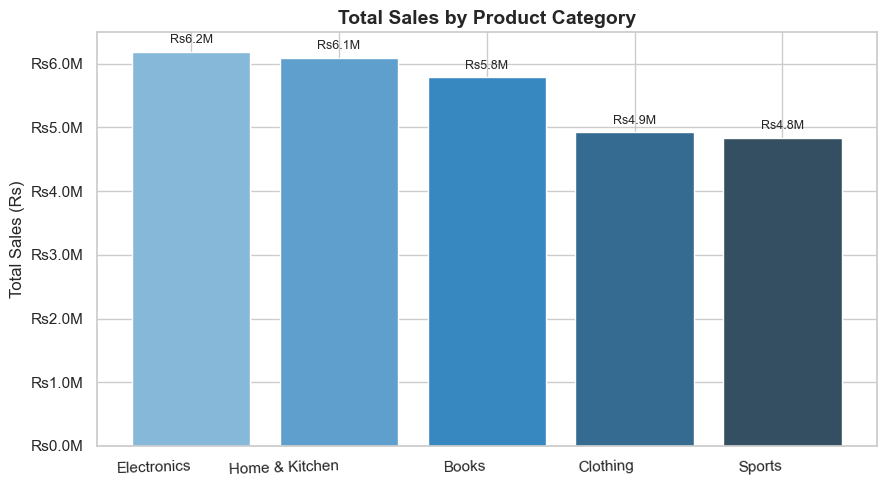

Chart 1 saved.


In [17]:
# Chart 1: Sales by Category (Bar)
cat_sales = master_plot.groupby('category')['item_total'].sum().sort_values(ascending=False).dropna()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cat_sales.index, cat_sales.values,
              color=sns.color_palette('Blues_d', len(cat_sales)), edgecolor='white')
ax.bar_label(bars, labels=[f'Rs{v/1e6:.1f}M' for v in cat_sales.values], padding=4, fontsize=9)
ax.set_title('Total Sales by Product Category', fontsize=14, fontweight='bold')
# ax.set_xlabel('Category')
ax.set_ylabel('Total Sales (Rs)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs{x/1e6:.1f}M'))
ax.set_xticklabels(cat_sales.index, rotation=2, ha='right')
plt.tight_layout()
plt.savefig(f'{VIZ}/01_sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

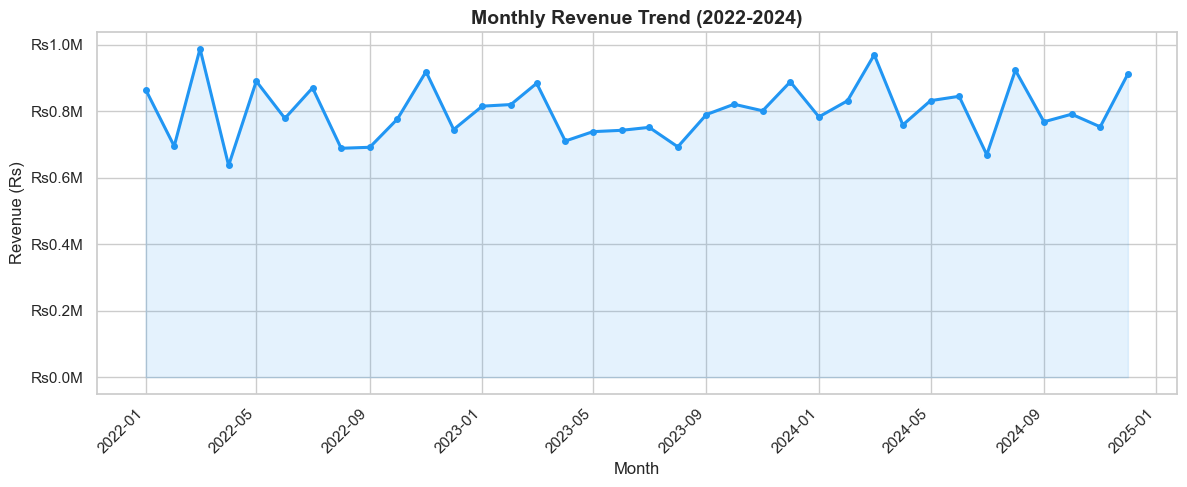

Chart 2 saved.


In [18]:
# Chart 2: Monthly Revenue Trend (Line)
monthly = orders_plot.groupby('order_month_dt')['net_amount'].sum().reset_index()
monthly.columns = ['month', 'revenue']
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly['month'], monthly['revenue'], color='#2196F3', linewidth=2.2, marker='o', markersize=4)
ax.fill_between(monthly['month'], monthly['revenue'], alpha=0.12, color='#2196F3')
ax.set_title('Monthly Revenue Trend (2022-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (Rs)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs{x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{VIZ}/02_monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

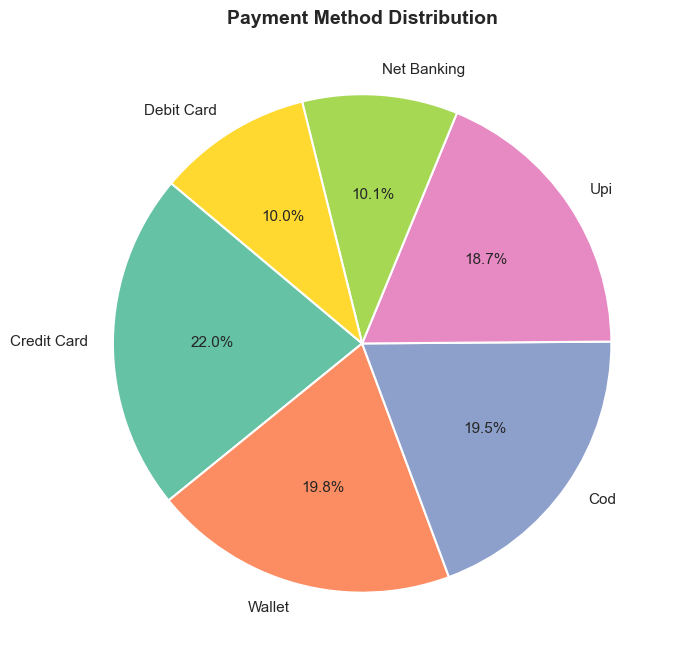

Chart 3 saved.


In [19]:
# Chart 3: Payment Method Pie
pay = orders_plot['payment_method'].value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(pay.values, labels=pay.index, autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(pay)), startangle=140,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{VIZ}/03_payment_method_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

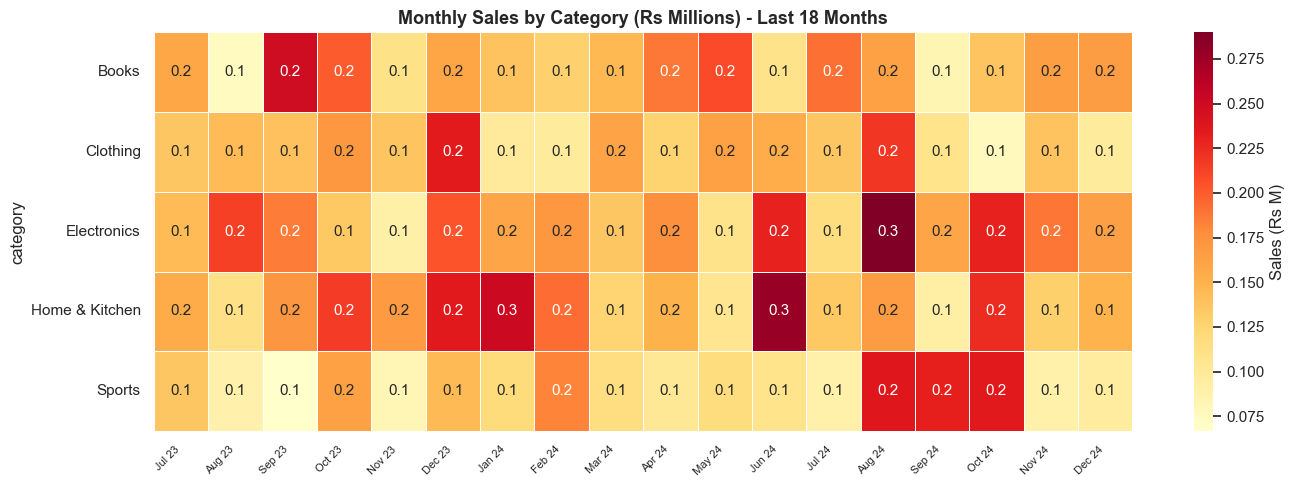

Chart 4 saved.


In [20]:
# Chart 4: Heatmap - Monthly Sales by Category
pivot = master_plot.groupby(['category', 'month_dt'])['item_total'].sum().unstack(fill_value=0)
pivot = pivot[sorted(pivot.columns)[-18:]]
pivot.columns = [c.strftime('%b %y') for c in pivot.columns]
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot / 1e6, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Sales (Rs M)'})
ax.set_title('Monthly Sales by Category (Rs Millions) - Last 18 Months', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{VIZ}/04_heatmap_monthly_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

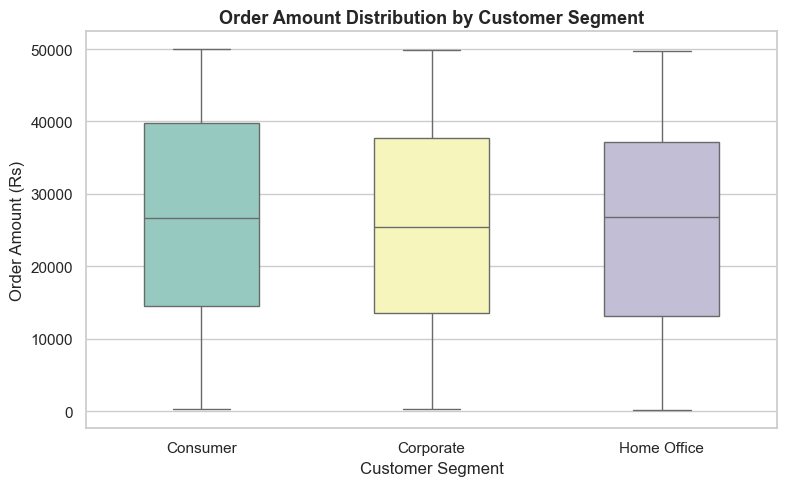

Chart 5 saved.


In [21]:
# Chart 5: Box Plot - Order Amount by Segment
seg_data = master_plot[master_plot['customer_segment'].notna() & master_plot['order_amount'].notna()]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=seg_data, x='customer_segment', y='order_amount',
            palette='Set3', width=0.5,
            flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)
ax.set_title('Order Amount Distribution by Customer Segment', fontsize=13, fontweight='bold')
ax.set_xlabel('Customer Segment')
ax.set_ylabel('Order Amount (Rs)')
plt.tight_layout()
plt.savefig(f'{VIZ}/05_boxplot_segment_orders.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

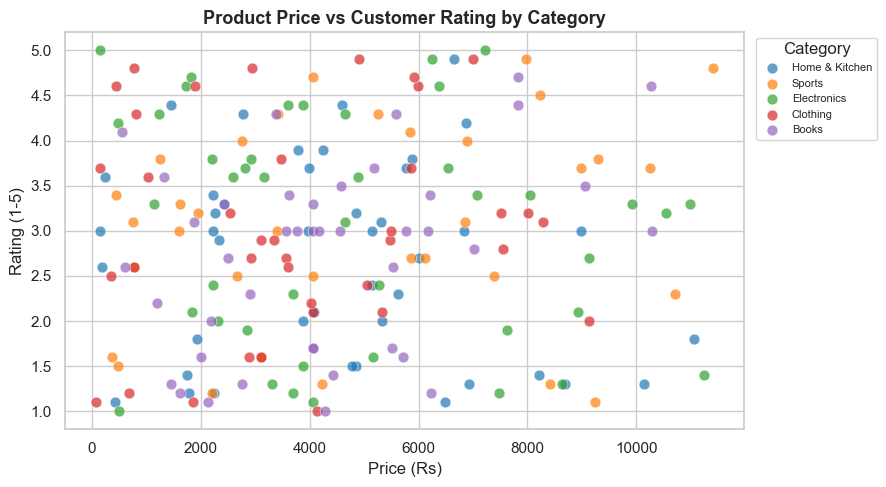

Chart 6 saved.


In [22]:
# Chart 6: Scatter - Price vs Rating
fig, ax = plt.subplots(figsize=(9, 5))
cats = prod['category'].unique()
palette = sns.color_palette('tab10', len(cats))
for i, cat in enumerate(cats):
    sub = prod[prod['category'] == cat]
    ax.scatter(sub['price'], sub['rating'], label=cat,
               color=palette[i], alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
ax.set_title('Product Price vs Customer Rating by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Price (Rs)')
ax.set_ylabel('Rating (1-5)')
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{VIZ}/06_scatter_price_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved.")

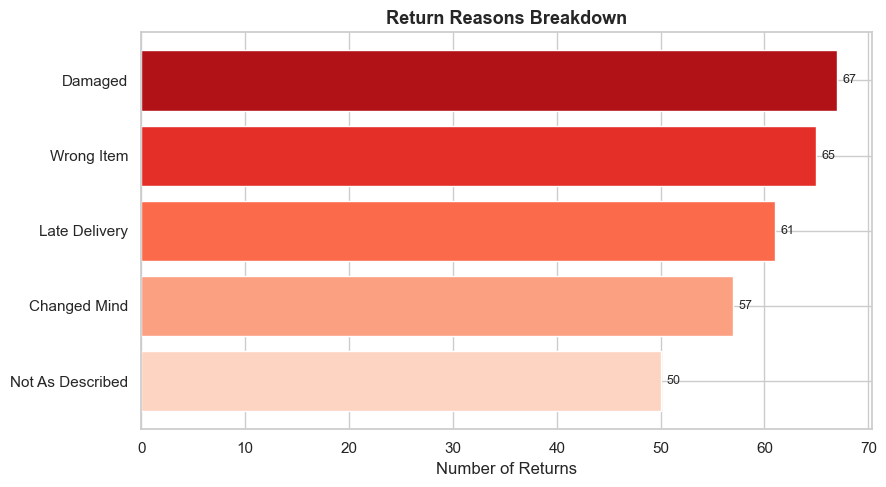

Chart 7 saved.


In [23]:
# Chart 7: Return Reasons (Horizontal Bar)
reasons = ret['return_reason'].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(reasons.index, reasons.values,
               color=sns.color_palette('Reds_r', len(reasons)), edgecolor='white')
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title('Return Reasons Breakdown', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Returns')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{VIZ}/07_return_reasons.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved.")

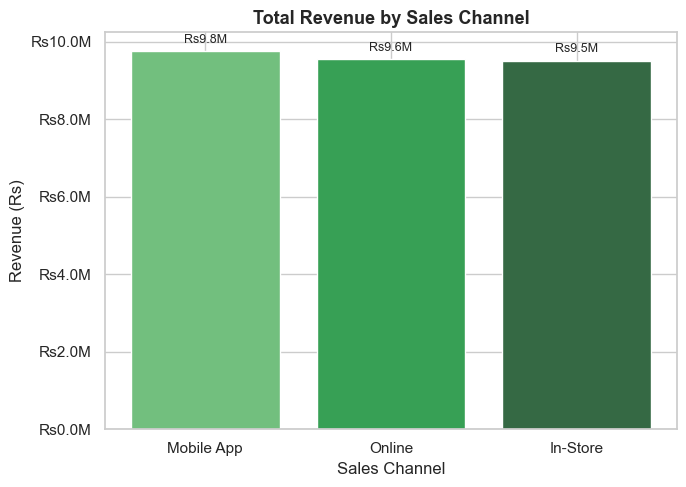

Chart 8 saved.


In [24]:
# Chart 8: Revenue by Sales Channel (Bar)
channel = orders_plot.groupby('sales_channel')['net_amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(channel.index, channel.values,
              color=sns.color_palette('Greens_d', len(channel)), edgecolor='white')
ax.bar_label(bars, labels=[f'Rs{v/1e6:.1f}M' for v in channel.values], padding=4, fontsize=9)
ax.set_title('Total Revenue by Sales Channel', fontsize=13, fontweight='bold')
ax.set_xlabel('Sales Channel')
ax.set_ylabel('Revenue (Rs)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig(f'{VIZ}/08_revenue_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved.")

## Step 14 — Before vs After Summary

In [25]:
raw_shapes = {'customers': (1000, 8), 'products': (200, 9),
              'orders': (1500, 12), 'order_items': (3000, 6), 'returns': (300, 6)}
clean_dfs  = {'customers': cust, 'products': prod,
              'orders': orders, 'order_items': items, 'returns': ret}

print('=' * 60)
header = f"  {'File':<18} {'Raw Rows':>10} {'Clean Rows':>12} {'Diff':>8}"
print(header)
print('=' * 60)
for name, (raw_r, raw_c) in raw_shapes.items():
    clean_r = len(clean_dfs[name])
    diff = clean_r - raw_r
    row = f'  {name:<18} {raw_r:>10} {clean_r:>12} {diff:>+8}'
    print(row)
print('=' * 60)
print(f'  master_table: {master.shape[0]} rows x {master.shape[1]} columns')
print('=' * 60)

  File                 Raw Rows   Clean Rows     Diff
  customers                1000          952      -48
  products                  200          200       +0
  orders                   1500         1398     -102
  order_items              3000         2799     -201
  returns                   300          300       +0
  master_table: 2845 rows x 31 columns


---
## What We Learned

| Skill | Code Used |
|-------|-----------|
| Load multiple CSVs | `pd.read_csv()` for each file |
| Full data audit | `isnull()`, `duplicated()`, `dtypes`, `unique()` |
| Robust date parsing | Custom `parse_single_date()` with 11 formats |
| Regex email validation | `re.match(r'^[\w\.-]+@...')` |
| Regex phone cleaning | `re.sub(r'\D', '', phone)` |
| Smart missing value fill | `fillna(median)`, `ffill()`, `bfill()` |
| Business logic fix | Discount > order_amount → set to 0 |
| Recalculate derived cols | `qty × price × (1 - disc/100)` |
| Merge multiple DataFrames | `df.merge(on=..., how='left')` chained 3x |
| GroupBy aggregations | `groupby().sum()`, `groupby().value_counts()` |
| 8 chart types | Bar, Line, Pie, Heatmap, Boxplot, Scatter |
| Export cleaned data | `df.to_csv(index=False)` |

---